# Assignment 4

## Note:

Please replace the variable: **project_list_path** with the location of project list for landbosse. This is how the code switches landbosse inputs. After the fact, there will be **project_list_defualt.xlsx** file which was the original Project List file which you can replace if need be.

# Importing Modules

In [182]:
import os
import numpy as np
from landbosse.main_function import run_landbosse # type: ignore
import landbosse # type: ignore
import floris
from floris import FlorisModel, TimeSeries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import floris.flow_visualization as flowviz
from pathlib import Path

from scipy.optimize import brentq

import warnings
warnings.filterwarnings("ignore")

# Inputs

## Turbine

In [183]:
Rated_Power = 3370
Rated_Wind_Speed = 9.8
Cut_in_Wind_Speed = 3
Cut_out_Wind_Speed = 25
Rotor_Diameter = 130
Hub_Height = 120

## Floris

In [184]:
ti = 0.06           # m
d_wd = 5            # deg (Discretization Step)
d_ws = 2            # m/s (Discretization Step)

turbine_spacing = 5
turbine_spacing_8D = 8

x = [0,0,0]         # m
y = [0, turbine_spacing*Rotor_Diameter, 2*turbine_spacing*Rotor_Diameter]  # m

# 8D Spacing
x_8D = [0,0,0]         # m
y_8D = [
        0,
        turbine_spacing_8D*Rotor_Diameter,
        2*turbine_spacing_8D*Rotor_Diameter
    ] # m

windshear = 0.14
Air_Density = 1.225

## LandBOSSE

In [185]:
Substation_coordinate = np.array([500, turbine_spacing*Rotor_Diameter])
Turbine_coordinates = np.array([[i,j] for i,j in zip(x,y)])

Substation_coordinate_8D = np.array([500, 8*Rotor_Diameter])
Turbine_coordinates_8D = np.array([[i,j] for i,j in zip(x_8D,y_8D)])

project_list_path = Path("/home/lavender/Studies/Design of Wind Farms/modules/LandBOSSE/input/project_list.xlsx")
backup_path = project_list_path.with_name("project_list_backup.xlsx")
default_path = project_list_path.with_name(f"{project_list_path.stem}_default{project_list_path.suffix}")

Cable_Voltage = 30                  # in [kV]. Available: 10,20,30,45,60 kV
Fuel_Cost = 5.19                    # $/gal
line_frequency = 50                 # Hz.
array_voltage = 30                  # kV.
turbine_cost = 1.3*1e6              # million per megawatt (MW).
O_M_cost = 0.016                    # $/kWh.
rental_payment_for_land = 20000     # $/MW-yr.
discount_rate = 4                   # %
design_lifetime_of_the_farm = 20    # years.
project_construction_time = 12      # months.

# 1. Create and Plot WindRose

## Load from File

In [186]:
df = pd.read_csv(
    "/home/lavender/Studies/Design of Wind Farms/Tutorial/Week4/sample_time_series.csv"
    )

print(df.shape)

df.head()

(244080, 3)


,t_h,ws_HH_m/s,wd_HH_deg
0,0.0,6.374859,340.909111
1,0.5,6.369563,332.244448
2,1.0,6.577082,327.540863
3,1.5,7.023411,321.591873
4,2.0,7.194065,317.794319


## Extracting Data

In [187]:
wd = df.wd_HH_deg

wd.head()

0    340.909111
1    332.244448
2    327.540863
3    321.591873
4    317.794319
Name: wd_HH_deg, dtype: float64

In [188]:
ws = df["ws_HH_m/s"]

ws.head()

0    6.374859
1    6.369563
2    6.577082
3    7.023411
4    7.194065
Name: ws_HH_m/s, dtype: float64

In [189]:
ws = np.array(ws)
wd = np.array(wd)

print(ws.shape)

ws

(244080,)


array([ 6.37485934,  6.36956303,  6.57708181, ..., 20.72947294,
       21.84342605, 22.8937329 ], shape=(244080,))

## Create Floris TimeSeries

In [190]:
time_series = TimeSeries(wind_directions=wd, wind_speeds=ws,
                         turbulence_intensities=ti)

In [191]:
wind_rose = time_series.to_WindRose(wd_edges=np.arange(0,360,d_wd),
                                    ws_edges=np.arange(0,30,d_ws))

## Visualizing Wind Rose

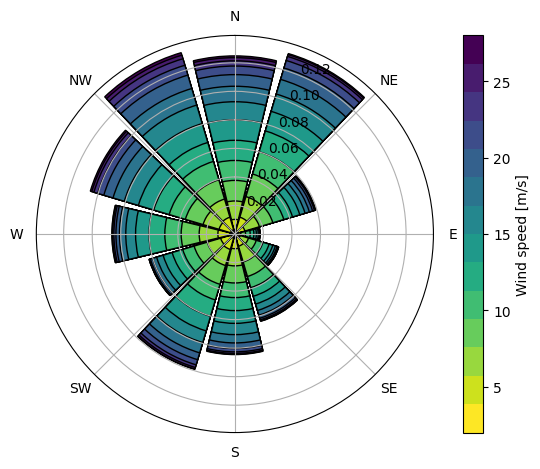

In [192]:
wind_rose.plot(wd_step=30, ws_step=2)

plt.savefig('wind_rose.png', dpi=150, bbox_inches='tight')

# 2. AEP and Wind Farm Efficiency

## Setting Wind Rose Discretiser

In [193]:
d_ws = 1
d_wd = 1

time_series = TimeSeries(wind_directions=wd, wind_speeds=ws,
                         turbulence_intensities=ti)

wind_rose = time_series.to_WindRose(wd_edges=np.arange(0,360,d_wd),
                                    ws_edges=np.arange(0,30,d_ws))

## Initiate Floris

In [194]:
fmodel = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/gch.yaml")
fmodel.set(layout_x=x,layout_y=y,wind_data=wind_rose,
           wind_shear=windshear)

fmodel_no_wake = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/gch.yaml")
fmodel_no_wake.set(layout_x=x,layout_y=y,wind_data=wind_rose,
           wind_shear=windshear)

## Run Floris

In [195]:
fmodel.run()
fmodel_no_wake.run_no_wake()

## Calculating AEP

In [196]:
AEP = fmodel.get_farm_AEP()
AEP_no_wake = fmodel_no_wake.get_farm_AEP()

AEP

np.float64(57210354917.05165)

## Calculating Capacity Factor

In [197]:
CF = fmodel.get_farm_AEP()/((365*24*60*60)*(Rated_Power))

print(f"Capacity Factor: {CF*100:.3f} %")

Capacity Factor: 53.832 %


## Wind Farm Efficiency

In [198]:
WFE = AEP/AEP_no_wake

print(f"Wind Farm Efficiency: {WFE*100:.3f} %")

Wind Farm Efficiency: 98.613 %


# 3. LandBOSSE

## Calculating Rated Thrust

In [199]:
# Set FLORIS to rated wind speed to get Ct at rated
fmodel_rated = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/gch.yaml")
fmodel_rated.set(
    wind_speeds=[Rated_Wind_Speed],
    wind_directions=[270.0],
    turbulence_intensities=[ti],
    layout_x=[0.0],
    layout_y=[0.0],
)
fmodel_rated.run()

Ct_rated = fmodel_rated.get_turbine_thrust_coefficients()[0, 0]
A = np.pi * (Rotor_Diameter / 2)**2
Turbine_Rated_Thrust = 0.5 * Air_Density * A * Rated_Wind_Speed**2 * Ct_rated

print(f"Ct_rated: {Ct_rated:.4f}")
print(f"Rated Thrust: {Turbine_Rated_Thrust/1000:.1f} kN")

Ct_rated: 0.8015
Rated Thrust: 625.8 kN


## Restoring Backup

In [200]:
# Replace existing default file if it exists
if default_path.exists():
    default_path.unlink()

# Move current project_list.xlsx to project_list_default.xlsx
if project_list_path.exists():
    shutil.move(str(project_list_path), str(default_path))

# Copy backup back to project_list.xlsx
shutil.copy(str(backup_path), str(project_list_path))

print(f"Moved current file to: {default_path}")
print(f"Restored from backup: {backup_path}")

Moved current file to: /home/lavender/Studies/Design of Wind Farms/modules/LandBOSSE/input/project_list_default.xlsx
Restored from backup: /home/lavender/Studies/Design of Wind Farms/modules/LandBOSSE/input/project_list_backup.xlsx


## Extracting Project List from LandBOSSE

In [201]:
WriteExcel = False
Display = True

old_projects = pd.read_excel(project_list_path)

old_projects

,Project ID,Project data file,Total project construction time (months),Turbine rating MW,Hub height m,Rotor diameter m,Turbine spacing (times rotor diameter),Row spacing (times rotor diameter),Number of turbines,Breakpoint between base and topping (percent),...,Allow same flag,Override total management cost for distributed (0 does not override),Markup contingency,Markup warranty management,Markup sales and use tax,Markup overhead,Markup profit margin,Utility Interconnection Fees (Small DW only),Labor cost multiplier,Crane breakdown fraction
0,ge15_dist_01,ge15_public_dist,1,1.5,80,77,4,10,1,0.0,...,n,1519250,0.03,0.0002,0,0.05,0.05,0,1,0
1,ge15_dist_05,ge15_public_dist,1,1.5,80,77,4,10,5,0.0,...,n,1519250,0.03,0.0002,0,0.05,0.05,0,1,0
2,ge15_dist_10,ge15_public_dist,1,1.5,80,77,4,10,10,0.0,...,n,1519250,0.03,0.0002,0,0.05,0.05,0,1,0
3,foundation_validation_ge15,ge15_public,9,1.5,80,77,4,10,100,0.8,...,n,0,0.03,0.0002,0,0.05,0.05,0,1,0
4,foundation_validation_clipper25,clipper_25_public,9,2.5,80,96,4,10,60,0.7,...,n,0,0.03,0.0002,0,0.05,0.05,0,1,0
5,foundation_validation_iea36_85,iea36_85_project_data,9,3.6,85,130,4,10,28,0.7,...,n,0,0.03,0.0002,0,0.05,0.05,0,1,0
6,foundation_validation_iea36_120,iea36_120_project_data,9,3.6,120,130,4,10,28,0.5,...,n,0,0.03,0.0002,0,0.05,0.05,0,1,0


## Change Backup to 1 Row DF

In [202]:
old_projects = pd.DataFrame(old_projects.iloc[[0]])

old_projects

,Project ID,Project data file,Total project construction time (months),Turbine rating MW,Hub height m,Rotor diameter m,Turbine spacing (times rotor diameter),Row spacing (times rotor diameter),Number of turbines,Breakpoint between base and topping (percent),...,Allow same flag,Override total management cost for distributed (0 does not override),Markup contingency,Markup warranty management,Markup sales and use tax,Markup overhead,Markup profit margin,Utility Interconnection Fees (Small DW only),Labor cost multiplier,Crane breakdown fraction
0,ge15_dist_01,ge15_public_dist,1,1.5,80,77,4,10,1,0.0,...,n,1519250,0.03,0.0002,0,0.05,0.05,0,1,0


In [203]:
# path = "/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/project_list2.xlsx"

# old_projects.to_excel(path)

## Editing Project List

In [204]:
projects = old_projects.copy()

projects["Project ID"] = ["Assignment 4"]
projects["Project data file"] = "iea36_120_project_data"
projects["Total project construction time (months)"] = project_construction_time
projects["Hub height m"] = Hub_Height
projects["Rotor diameter m"] = Rotor_Diameter
projects["Turbine spacing (times rotor diameter)"] = turbine_spacing
projects["Line Frequency (Hz)"] = line_frequency
projects["Number of turbines"] = 3
projects["Fuel cost USD per gal"] = Fuel_Cost
projects["Wind shear exponent"] = windshear
projects["Turbine rating MW"] = Rated_Power/1e3
projects["Row spacing (times rotor diameter)"] = 0
projects["Rated Thrust (N)"] = Turbine_Rated_Thrust


# Write the updated projects DataFrame
projects.to_excel(project_list_path, index=False)

### Discard: Project list will only ever run the first row (I think lol)
# new_row = projects.copy()

# new_row["Project ID"] = ["Assignment 4 8D"]
# new_row["Turbine spacing (times rotor diameter)"] = 8

# new_df = pd.DataFrame([new_row])
# projects = pd.concat([projects, new_row], ignore_index=True)

projects

,Project ID,Project data file,Total project construction time (months),Turbine rating MW,Hub height m,Rotor diameter m,Turbine spacing (times rotor diameter),Row spacing (times rotor diameter),Number of turbines,Breakpoint between base and topping (percent),...,Allow same flag,Override total management cost for distributed (0 does not override),Markup contingency,Markup warranty management,Markup sales and use tax,Markup overhead,Markup profit margin,Utility Interconnection Fees (Small DW only),Labor cost multiplier,Crane breakdown fraction
0,Assignment 4,iea36_120_project_data,12,3.37,120,130,5,0,3,0.0,...,n,1519250,0.03,0.0002,0,0.05,0.05,0,1,0


### Sanity Check for Non-Edited Project Settings

In [205]:
left = []

keys_old = list(old_projects.to_dict().keys())
keys = list(projects.to_dict().keys())

for i in range(len(keys)):
    oldval = old_projects[keys[i]][0]
    
    newval = projects[keys[i]][0]
    
    if old_projects[keys[i]][0] == projects[keys[i]][0]:
        left.append(keys[i])
        
        # print(oldval)
        # print()
        # print(newval)
        # print()
        # print()

left

# old_projects.keys()

['Breakpoint between base and topping (percent)',
 'Rate of deliveries (turbines per week)',
 'Foundation depth m',
 'Bearing Pressure (n/m2)',
 '50-year Gust Velocity (m/s)',
 'Flag for user-defined home run trench length (0 = no; 1 = yes)',
 'Combined Homerun Trench Length to Substation (km)',
 'Non-Erection Wind Delay Critical Height (m)',
 'Non-Erection Wind Delay Critical Speed (m/s)',
 'Distance to interconnect (miles)',
 'Interconnect Voltage (kV)',
 'New Switchyard (y/n)',
 'Road length adder (m)',
 'Road Quality (0-1)',
 'Percent of roads that will be constructed',
 'Road width (ft)',
 'Road thickness (in)',
 'Calculate road cost for distributed wind? (y/n)',
 'Site prep area for Distributed wind (m2)',
 'Crane width (m)',
 'Number of highway permits',
 'Number of access roads',
 'Overtime multiplier',
 'Allow same flag',
 'Override total management cost for distributed (0 does not override)',
 'Markup contingency',
 'Markup warranty management',
 'Markup sales and use tax',
 

## Setting New Project List

In [206]:
if not os.path.exists(path_backup):          # avoid overwriting backup on re-runs
    os.rename(project_list_path, path_backup)

# Write the updated projects DataFrame to the original path
projects.to_excel(project_list_path, index=False)

print(f"Backup saved to: {path_backup}")
print(f"New project list written to: {project_list_path}")

Backup saved to: /home/lavender/Studies/Design of Wind Farms/modules/LandBOSSE/input/project_list_backup.xlsx
New project list written to: /home/lavender/Studies/Design of Wind Farms/modules/LandBOSSE/input/project_list.xlsx


## Actually Running

In [207]:
# Run
landbosse_results = run_landbosse(Turbine_coordinates, Substation_coordinate, Cable_Voltage, WriteExcel, Display)

>>>>>>>> Begin run 2026-05-13 11:11:54.272214 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx


## Seeing Results

In [208]:
landbosse_results

,Project ID with serial,Number of turbines,Turbine rating MW,Rotor diameter m,Module,Type of cost,Cost per turbine,Cost per project,Cost per kW
0,Assignment 4,3,3.37,130,FoundationCost,Equipment rental,4951.840212,1.485552e+04,1.469389
1,Assignment 4,3,3.37,130,FoundationCost,Labor,260943.576854,7.828307e+05,77.431328
2,Assignment 4,3,3.37,130,FoundationCost,Materials,91005.905941,2.730177e+05,27.004720
3,Assignment 4,3,3.37,130,FoundationCost,Mobilization,8139.034719,2.441710e+04,2.415144
4,Assignment 4,3,3.37,130,SitePreparationCost,Materials,8862.996187,2.658899e+04,2.629969
5,Assignment 4,3,3.37,130,SitePreparationCost,Equipment rental,3948.428299,1.184528e+04,1.171640
6,Assignment 4,3,3.37,130,SitePreparationCost,Labor,21753.003822,6.525901e+04,6.454897
7,Assignment 4,3,3.37,130,SitePreparationCost,Other,245396.333333,7.361890e+05,72.817903
8,Assignment 4,3,3.37,130,SitePreparationCost,Mobilization,19153.280295,5.745984e+04,5.683466
9,Assignment 4,3,3.37,130,SubstationCost,Other,0.000000,0.000000e+00,0.000000


## Extract total Balance-of-Plant cost from LandBOSSE

In [209]:
bop_cost = landbosse_results['Cost per project'].sum()

print(f"BoP Cost:               ${bop_cost:,.0f}")

bop_by_module = landbosse_results.groupby('Module')['Cost per project'].sum().sort_values(ascending=False)
print("\nBoP breakdown by module:")
print(bop_by_module.apply(lambda x: f"  ${x:,.0f}").to_string())

BoP Cost:               $6,820,508

BoP breakdown by module:
Module
ManagementCost           $1,519,250
GridConnectionCost       $1,429,498
FoundationCost           $1,095,121
ErectionCost             $1,008,541
SitePreparationCost        $897,342
TransportCost              $624,000
DevelopmentCost            $150,000
CollectionCost              $96,755
SubstationCost                   $0


## Turbine capital cost

In [210]:
n_turbines   = 3
Total_MW     = (Rated_Power / 1e3) * n_turbines         # MW  (3.37 * 3 = 10.11)
turbine_cost_total = turbine_cost * Total_MW            # USD  (turbine_cost = 1.3e6 $/MW)
print(f"Turbine Cost:\t${turbine_cost_total:,.0f}")

Turbine Cost:	$13,143,000


## Initial Capital Cost (ICC)

In [211]:
ICC = turbine_cost_total + bop_cost
print(f"ICC (Turbine + BoP):\t${ICC:,.0f}")

ICC (Turbine + BoP):	$19,963,508


## Annuity (A)

In [212]:
r = discount_rate / 100                                  # 0.04
n = design_lifetime_of_the_farm                          # 20 years
Annuity = (((1 + r)**n) - 1) / (r * ((1 + r)**n))

print(f"Annuity:\t\t{Annuity:.6f}")

Annuity:		13.590326


## Annual costs

In [213]:
AEP_kWh = AEP / 1e3                                     # Wh → kWh  (FLORIS returns Wh)
C_OM_annual   = O_M_cost * AEP_kWh                      # $/yr  (0.016 $/kWh * kWh/yr)
C_land_annual = rental_payment_for_land * Total_MW       # $/yr  (20000 $/MW-yr * MW)
print(f"Annual O&M Cost:        ${C_OM_annual:,.0f}")
print(f"Annual Land Rental:     ${C_land_annual:,.0f}")

Annual O&M Cost:        $915,366
Annual Land Rental:     $202,200


## LCOE

In [214]:
LCOE = (ICC / (AEP_kWh * Annuity)) + ((C_OM_annual + C_land_annual) / AEP_kWh)  # $/kWh

LCOE_MWh = LCOE * 1e3

print(f"\n{''*40}")
print(f"AEP:                    {AEP_kWh/1e6:.3f} GWh/yr")
print(f"LCOE:                   {LCOE:.4f} $/kWh")
print(f"LCOE:                   {LCOE_MWh:.2f} $/MWh")



AEP:                    57.210 GWh/yr
LCOE:                   0.0452 $/kWh
LCOE:                   45.21 $/MWh


# 4. LCOE Literature Comparison + Cost Breakdown

## Literature Comparision

In [215]:
# Typical onshore wind LCOE ranges (2023-2024, IEA / IRENA):
#   Global weighted average: ~33 $/MWh  (IRENA 2023)
#   Europe onshore:          ~40-60 $/MWh
#   Small / 3-turbine farms: higher due to no economies of scale
lit_low, lit_high = 33, 70   # $/MWh - reasonable range for onshore wind

print("LCOE Comparison with Literature")
print(f"\n\tCalculated LCOE:       {LCOE_MWh:.2f} $/MWh")
print(f"\tLiterature range:      {lit_low}-{lit_high} $/MWh  (IRENA/IEA, onshore wind)")

if lit_low <= LCOE_MWh <= lit_high:
    print("\n\tWithin typical literature range.")
else:
    print(f"\n\tOutside typical range - likely due to small project size (only 3 turbines),")
    print(f"\n\twhich raises specific BoP costs per MW significantly.")

LCOE Comparison with Literature

	Calculated LCOE:       45.21 $/MWh
	Literature range:      33-70 $/MWh  (IRENA/IEA, onshore wind)

	Within typical literature range.


## Cost Components

In [216]:

C_turbine_annual = turbine_cost_total / Annuity   # annualised turbine CAPEX
C_bop_annual     = bop_cost / Annuity             # annualised BoP CAPEX

labels = ['Turbine Investment', 'Balance-of-Plant', 'O&M', 'Land Rental']
costs  = [C_turbine_annual, C_bop_annual, C_OM_annual, C_land_annual]

print("Annualised Cost Breakdown\n")
for l, c in zip(labels, costs):
    print(f"\t{l:<25} ${c:>12,.0f} /yr  ({c/sum(costs)*100:.1f}%)")
print(f"\t{'Total':<25} ${sum(costs):>12,.0f} /yr")

Annualised Cost Breakdown

	Turbine Investment        $     967,085 /yr  (37.4%)
	Balance-of-Plant          $     501,865 /yr  (19.4%)
	O&M                       $     915,366 /yr  (35.4%)
	Land Rental               $     202,200 /yr  (7.8%)
	Total                     $   2,586,516 /yr


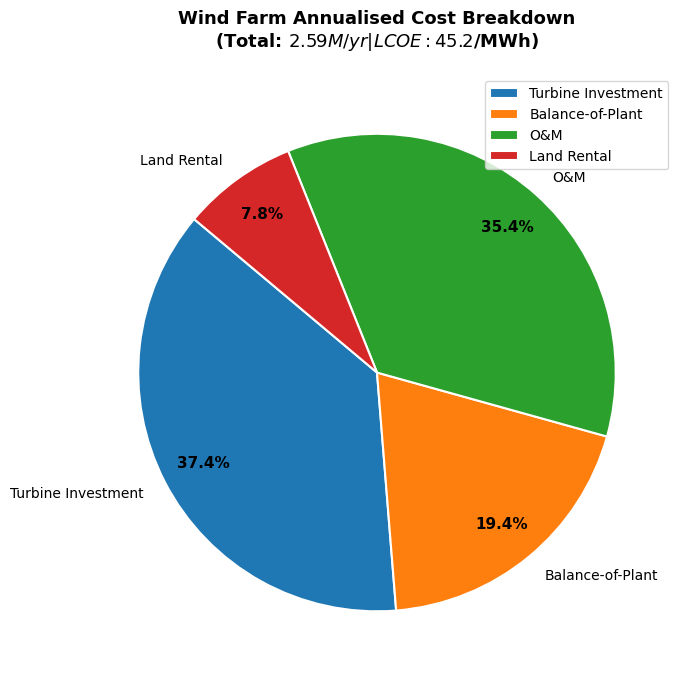

In [217]:
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    costs,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax.set_title(
    f'Wind Farm Annualised Cost Breakdown\n'
    f'(Total: ${sum(costs)/1e6:.2f} M/yr | LCOE: {LCOE_MWh:.1f} $/MWh)',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('cost_breakdown_pie.png', dpi=150, bbox_inches='tight')
plt.legend()
plt.show()

# 5. 8D to 5D Comparision

## Floris Run

In [218]:
fmodel_8D = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/gch.yaml")
fmodel_8D.set(layout_x=x_8D,layout_y=y_8D,wind_data=wind_rose,
           wind_shear=windshear)

In [219]:
fmodel_8D.run()

In [220]:
AEP_8D = fmodel_8D.get_farm_AEP() / 1e3        # Wh → kWh

AEP_8D

np.float64(57627520.49856523)

In [221]:
#  Q5: 8D Separation - LandBOSSE Run 

# Step 1: Build the 8D-only project row
projects_8D = old_projects.copy()

projects_8D["Project ID"]                              = ["Assignment 4 8D"]
projects_8D["Project data file"]                       = "iea36_120_project_data"
projects_8D["Total project construction time (months)"]= project_construction_time
projects_8D["Hub height m"]                            = Hub_Height
projects_8D["Rotor diameter m"]                        = Rotor_Diameter
projects_8D["Turbine spacing (times rotor diameter)"]  = turbine_spacing_8D   # 8
projects_8D["Line Frequency (Hz)"]                     = line_frequency
projects_8D["Number of turbines"]                      = 3
projects_8D["Fuel cost USD per gal"]                   = Fuel_Cost
projects_8D["Wind shear exponent"]                     = windshear
projects_8D["Turbine rating MW"]                       = Rated_Power / 1e3
projects_8D["Row spacing (times rotor diameter)"]      = 0
projects_8D["Rated Thrust (N)"]                        = Turbine_Rated_Thrust

# Step 2: Write only the 8D row to project_list.xlsx (single row = one run)
projects_8D.to_excel(project_list_path, index=False)
print("8D project list written.")

# Step 3: Run LandBOSSE for 8D
landbosse_results_8D = run_landbosse(
    Turbine_coordinates_8D,
    Substation_coordinate_8D,
    Cable_Voltage,
    WriteExcel,
    Display
)

# Step 4: Restore the 5D project list for future cells
projects_5D = old_projects.copy()
projects_5D["Project ID"]                              = ["Assignment 4"]
projects_5D["Project data file"]                       = "iea36_120_project_data"
projects_5D["Total project construction time (months)"]= project_construction_time
projects_5D["Hub height m"]                            = Hub_Height
projects_5D["Rotor diameter m"]                        = Rotor_Diameter
projects_5D["Turbine spacing (times rotor diameter)"]  = turbine_spacing   # 5
projects_5D["Line Frequency (Hz)"]                     = line_frequency
projects_5D["Number of turbines"]                      = 3
projects_5D["Fuel cost USD per gal"]                   = Fuel_Cost
projects_5D["Wind shear exponent"]                     = windshear
projects_5D["Turbine rating MW"]                       = Rated_Power / 1e3
projects_5D["Row spacing (times rotor diameter)"]      = 0
projects_5D["Rated Thrust (N)"]                        = Turbine_Rated_Thrust
projects_5D.to_excel(project_list_path, index=False)
print("5D project list restored.")

8D project list written.
>>>>>>>> Begin run 2026-05-13 11:11:55.993335 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx
5D project list restored.


In [222]:
# 8D BoP + LCOE
bop_cost_8D       = landbosse_results_8D['Cost per project'].sum()
ICC_8D            = turbine_cost_total + bop_cost_8D   # turbine cost unchanged
C_OM_annual_8D    = O_M_cost * AEP_8D
LCOE_8D           = ((ICC_8D) / (AEP_8D * Annuity)) + (C_OM_annual_8D + C_land_annual) / AEP_8D
LCOE_MWh_8D       = LCOE_8D * 1e3

# Relative differences
delta_AEP  = (AEP_8D - AEP_kWh) / AEP_kWh * 100
delta_LCOE = (LCOE_MWh_8D - LCOE_MWh) / LCOE_MWh * 100

print(f"AEP  5D:\t{AEP_kWh/1e6:.3f} GWh/yr\t|\t8D: {AEP_8D/1e6:.3f} GWh/yr\t|\tΔ = {delta_AEP:+.2f}%")
print(f"LCOE 5D:\t{LCOE_MWh:.2f} $/MWh\t|\t8D: {LCOE_MWh_8D:.2f} $/MWh\t\t|\tΔ = {delta_LCOE:+.2f}%")

AEP  5D:	57.210 GWh/yr	|	8D: 57.628 GWh/yr	|	Δ = +0.73%
LCOE 5D:	45.21 $/MWh	|	8D: 45.06 $/MWh		|	Δ = -0.34%


# 6. Discount Rate Change

In [223]:
discount_rate_new = 0.9*discount_rate

r_new = discount_rate_new / 100                                  # 0.04

# LCOE at d = 3.6%
Annuity_new     = (((1 + r_new)**n) - 1) / (r_new * ((1 + r_new)**n))
LCOE_new        = ((ICC) / (AEP_kWh * Annuity_new)) + (C_OM_annual + C_land_annual) / AEP_kWh
LCOE_MWh_new    = LCOE_new * 1e3

delta_LCOE = (LCOE_MWh_new - LCOE_MWh) / LCOE_MWh * 100

print(
    f"LCOE 4%: {LCOE_MWh:.3f} $/MWh  |  3.6%: {LCOE_MWh_new:.3f} $/MWh  |  Δ = {delta_LCOE:+.3f}%")

LCOE 4%: 45.211 $/MWh  |  3.6%: 44.309 $/MWh  |  Δ = -1.993%


# 7. Improving Wind Farm

## Improvement Plan:

So here, staggering the location in x direction of the wind turbines, the following turbines will not be affected by the wake from the preceeding turbine. This helps in not just head on wind (North to South) but also the other directions as the wind turbines remain staggered

In [224]:
turbine_spacing = 5
turbine_spacing_x = 5

x_better = [0, turbine_spacing_x*Rotor_Diameter,-turbine_spacing_x*Rotor_Diameter]         # m
y_better = [0, turbine_spacing*Rotor_Diameter, 2*turbine_spacing*Rotor_Diameter]  # m

In [225]:
fmodel_better = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/gch.yaml")
fmodel_better.set(layout_x=x_better,layout_y=y_better,wind_data=wind_rose,
           wind_shear=windshear)
fmodel_better.run()

In [226]:
AEP_better = fmodel_better.get_farm_AEP()

improvement = ((AEP_better - AEP)/AEP) * 100

print(
f"""AEP:\t\t{AEP/1e9:.3f} GWh
Improved AEP:\t{AEP_better/1e9:.3f} GWh
Improvement:\t{improvement:.3f} %"""
    )

AEP:		57.210 GWh
Improved AEP:	57.626 GWh
Improvement:	0.727 %


# 8. IRR and Profitability Index

## Project parameters

In [227]:
electricity_price   = 41.8          # $/MWh  (given)
AEP_MWh             = AEP_kWh / 1e3  # convert kWh → MWh

# Annual revenue
annual_revenue = electricity_price * AEP_MWh       # $/yr

# Annual costs (O&M + land rental)
C_OM_annual    = O_M_cost * AEP_kWh                # $/yr  (0.016 $/kWh × AEP)
C_land_annual  = rental_payment_for_land * Total_MW # $/yr  (20 000 $/MW-yr × 10.11 MW)

# Annual net cash flow (revenue minus annual costs)
annual_cashflow = annual_revenue - C_OM_annual - C_land_annual  # $/yr

print(f"Annual Revenue:      ${annual_revenue:,.0f}")
print(f"Annual O&M Cost:     ${C_OM_annual:,.0f}")
print(f"Annual Land Rental:  ${C_land_annual:,.0f}")
print(f"Annual Net Cashflow: ${annual_cashflow:,.0f}")
print(f"Initial Investment:  ${ICC:,.0f}")

Annual Revenue:      $2,391,393
Annual O&M Cost:     $915,366
Annual Land Rental:  $202,200
Annual Net Cashflow: $1,273,827
Initial Investment:  $19,963,508


## NPV function

In [228]:
def npv(rate, initial_investment, cashflow, years):
    """Net Present Value for a constant annual cashflow."""
    if rate == 0:
        return cashflow * years - initial_investment
    annuity_factor = (((1 + rate)**years) - 1) / (rate * ((1 + rate)**years))
    return cashflow * annuity_factor - initial_investment

## Plot NPV vs Discount Rate

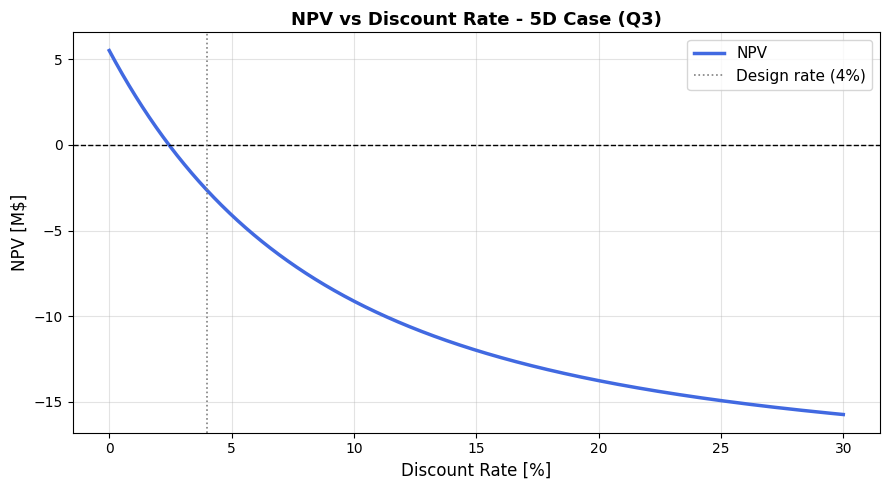

In [229]:
rates  = np.linspace(0.0, 0.30, 5000)           # 0 % - 30 %
npv_values = [npv(r_i, ICC, annual_cashflow, n) for r_i in rates]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rates * 100, np.array(npv_values) / 1e6, color='royalblue', lw=2.5, label='NPV')
ax.axhline(0, color='black', lw=1, ls='--')
ax.axvline(discount_rate, color='gray', lw=1.2, ls=':', label=f'Design rate ({discount_rate}%)')
ax.set_xlabel('Discount Rate [%]', fontsize=12)
ax.set_ylabel('NPV [M$]', fontsize=12)
ax.set_title('NPV vs Discount Rate - 5D Case (Q3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('q8_npv_vs_discount_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Numerical IRR Calculation


IRR: 2.443916 %


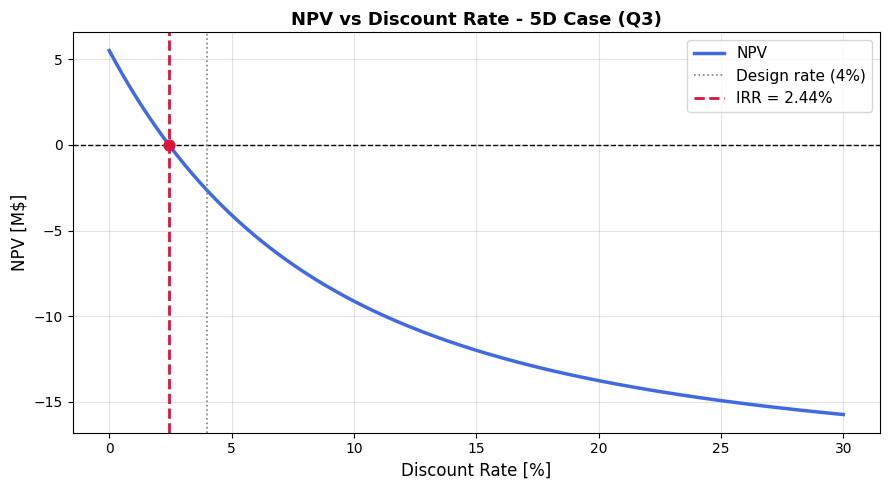

In [230]:
npv_at_0   = npv(1e-9, ICC, annual_cashflow, n)
npv_at_max = npv(0.30,  ICC, annual_cashflow, n)

if npv_at_0 > 0 and npv_at_max < 0:
    IRR = brentq(npv, 1e-9, 0.30, args=(ICC, annual_cashflow, n))
    print(f"\nIRR: {IRR*100:.6f} %")
elif npv_at_0 <= 0:
    IRR = None
    print("\nIRR: NPV is negative even at 0% → no real IRR (project never profitable)")
else:
    IRR = None
    print("\nIRR: NPV is positive at 30% → IRR > 30% (look beyond search range)")

# Mark IRR on the plot if found
if IRR is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(rates * 100, np.array(npv_values) / 1e6, color='royalblue', lw=2.5, label='NPV')
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.axvline(discount_rate, color='gray', lw=1.2, ls=':', label=f'Design rate ({discount_rate}%)')
    ax.axvline(IRR * 100, color='crimson', lw=2, ls='--', label=f'IRR = {IRR*100:.2f}%')
    ax.scatter([IRR * 100], [0], color='crimson', zorder=5, s=60)
    ax.set_xlabel('Discount Rate [%]', fontsize=12)
    ax.set_ylabel('NPV [M$]', fontsize=12)
    ax.set_title('NPV vs Discount Rate - 5D Case (Q3)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig('q8_npv_vs_discount_rate_irr.png', dpi=150, bbox_inches='tight')
    plt.show()

In [231]:
# ── Profitability Index (PI) ──────────────────────────────────
# PI = PV of future cashflows / Initial Investment
# PI > 1 → project creates value; PI < 1 → destroys value

r = 0.04
n = design_lifetime_of_the_farm

annuity_factor_4pct = (((1 + r)**n) - 1) / (r * ((1 + r)**n))       # r = 0.04 from Q3
PV_cashflows        = annual_cashflow * annuity_factor_4pct
PI                  = PV_cashflows / ICC

NPV_at_4pct         = npv(r, ICC, annual_cashflow, n)

print(f"\n── Profitability Index (PI) at {discount_rate}% ──")
print(f"PV of cashflows:  ${PV_cashflows:,.0f}")
print(f"Initial Invest.:  ${ICC:,.0f}")
print(f"NPV at {discount_rate}%:        ${NPV_at_4pct:,.0f}")
print(f"PI:               {PI:.4f}")

if PI > 1:
    print("\n✅ PI > 1: Project is economically ATTRACTIVE.")
else:
    print("\n❌ PI < 1: Project is NOT economically attractive.")
    print("\nWays to make the project viable:")
    print("  1. Higher electricity price (e.g. PPA > LCOE of ~38 $/MWh).")
    print("  2. Subsidies / feed-in tariffs to bridge the gap.")
    print("  3. Reduce CAPEX (turbine cost, BoP) or O&M expenses.")
    print("  4. Increase AEP (better siting, layout optimisation).")
    print("  5. Lower discount rate (e.g. public/green financing).")
    print("  6. Add more turbines to benefit from economies of scale.")


── Profitability Index (PI) at 4% ──
PV of cashflows:  $17,311,727
Initial Invest.:  $19,963,508
NPV at 4%:        $-2,651,781
PI:               0.8672

❌ PI < 1: Project is NOT economically attractive.

Ways to make the project viable:
  1. Higher electricity price (e.g. PPA > LCOE of ~38 $/MWh).
  2. Subsidies / feed-in tariffs to bridge the gap.
  3. Reduce CAPEX (turbine cost, BoP) or O&M expenses.
  4. Increase AEP (better siting, layout optimisation).
  5. Lower discount rate (e.g. public/green financing).
  6. Add more turbines to benefit from economies of scale.


# 9. LOCE and PI VS Number of Turbines

For the same case, estimate the minimum number of turbines in a straight North-South
line with a turbine spacing of 5D to achieve PI > 1. Compare LCOE and PI with growing
turbine number.

In [232]:
turbine_spacing_y = 5

In [233]:
fmodel = FlorisModel("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment4/gch.yaml")
fmodel.set(layout_x=x,layout_y=y,wind_data=wind_rose,
           wind_shear=windshear)

In [238]:
from tqdm import tqdm

xs = [i for i in range(1,51)]

AEPs = []
PIs = []
LCOEs = []

for n_turb in xs:
    x = [0 for _ in range(n_turb)]
    y = [int(i+1)*Rotor_Diameter for i in list(np.arange(n_turb))]

    fmodel.set(layout_x=x,layout_y=y,wind_data=wind_rose,
        wind_shear=windshear)

    fmodel.reset_operation()

    fmodel.run()

    AEP = fmodel.get_farm_AEP()

    # Step 4: Restore the 5D project list for future cells
    projects = old_projects.copy()
    projects["Project ID"]                              = ["Assignment 4"]
    projects["Project data file"]                       = "iea36_120_project_data"
    projects["Total project construction time (months)"]= project_construction_time
    projects["Hub height m"]                            = Hub_Height
    projects["Rotor diameter m"]                        = Rotor_Diameter
    projects["Turbine spacing (times rotor diameter)"]  = turbine_spacing   # 5
    projects["Number of turbines"]						= n_turb
    projects["Line Frequency (Hz)"]                     = line_frequency
    projects["Number of turbines"]                      = 3
    projects["Fuel cost USD per gal"]                   = Fuel_Cost
    projects["Wind shear exponent"]                     = windshear
    projects["Turbine rating MW"]                       = Rated_Power / 1e3
    projects["Row spacing (times rotor diameter)"]      = 0
    projects["Rated Thrust (N)"]                        = Turbine_Rated_Thrust
    projects.to_excel(project_list_path, index=False)
 
    # Step 3: Run LandBOSSE for 8D
    landbosse_results_8D = run_landbosse(
        Turbine_coordinates_8D,
        Substation_coordinate_8D,
        Cable_Voltage,
        WriteExcel,
        Display
    )
    
    # Annual revenue
    annual_revenue = electricity_price * AEP / 1e6      # $/yr
    C_OM_annual    = O_M_cost * AEP / 1e3               # $/yr
    
    # Annual net cash flow (revenue minus annual costs)
    annual_cashflow = annual_revenue - C_OM_annual - C_land_annual  # $/yr
    
    Total_MW     = (Rated_Power / 1e3) * n_turb         # MW
    turbine_cost_total = turbine_cost * Total_MW        # USD
    
    # 8D BoP + LCOE
    bop_cost       = landbosse_results['Cost per project'].sum()
    ICC            = turbine_cost_total + bop_cost   # turbine cost unchanged
    C_OM_annual    = O_M_cost * AEP
    LCOE           = ((ICC) / (AEP * Annuity)) + (C_OM_annual + C_land_annual) / AEP
    LCOE_MWh       = LCOE * 1e3
    
    r = 0.04
    n = design_lifetime_of_the_farm
    
    annuity_factor_4pct = (((1 + r)**n) - 1) / (r * ((1 + r)**n))       # r = 0.04 from Q3
    PV_cashflows        = annual_cashflow * annuity_factor_4pct
    PI                  = PV_cashflows / ICC

    NPV_at_4pct         = npv(r, ICC, annual_cashflow, n)
    
    PIs.append(PI)

    # print(f"\n── Profitability Index (PI) at {discount_rate}% ──")
    # print(f"PV of cashflows:  ${PV_cashflows:,.0f}")
    # print(f"Initial Invest.:  ${ICC:,.0f}")
    # print(f"NPV at {discount_rate}%:        ${NPV_at_4pct:,.0f}")
    # print(f"PI:               {PI:.4f}")
    
    # print(f"8D: {LCOE_MWh:.2f} $/MWh")
    
    AEPs.append(AEP)
    LCOEs.append(LCOE_MWh)

>>>>>>>> Begin run 2026-05-13 11:23:43.943483 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx
>>>>>>>> Begin run 2026-05-13 11:23:45.437415 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx
>>>>>>>> Begin run 2026-05-13 11:23:46.918120 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx


floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.


>>>>>>>> Begin run 2026-05-13 11:23:48.584647 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx


floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.


>>>>>>>> Begin run 2026-05-13 11:23:50.531761 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx


...

floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.


>>>>>>>> Begin run 2026-05-13 11:27:30.798493 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx


floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.


>>>>>>>> Begin run 2026-05-13 11:27:51.858103 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> Assignment 4 <><><><><><><><><><><><><><><><><><>
>>> project_id: Assignment 4
>>> Project data: input/project_data/iea36_120_project_data.xlsx


KeyboardInterrupt: 

In [240]:
xs = [i for i in range(1,28)]

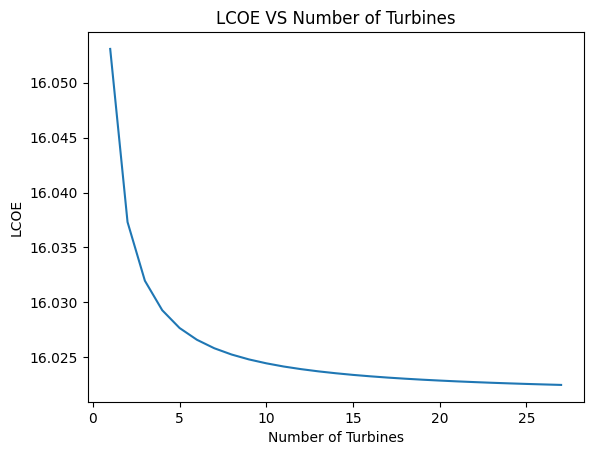

In [241]:
plt.plot(xs, LCOEs)
plt.xlabel("Number of Turbines")
plt.ylabel("LCOE")
plt.title("LCOE VS Number of Turbines")
plt.savefig('q9_lcoe_vs_turbines.png', dpi=150, bbox_inches='tight')

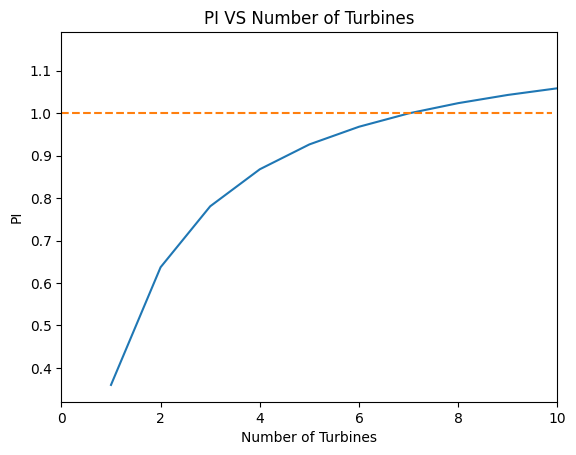

In [245]:
xlis = [i/10 for i in range(0,100)]
ylis = [1 for _ in range(0,100)]

plt.plot(xs, PIs)
plt.plot(xlis,ylis, '--')
plt.xlim(0,10)
plt.xlabel("Number of Turbines")
plt.ylabel("PI")
plt.title("PI VS Number of Turbines")
plt.savefig('q9_pi_vs_turbines.png', dpi=150, bbox_inches='tight')

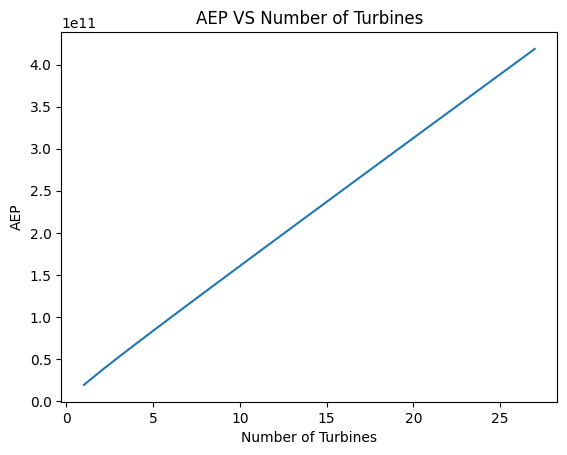

In [243]:
plt.plot(xs, AEPs)
plt.xlabel("Number of Turbines")
plt.ylabel("AEP")
plt.title("AEP VS Number of Turbines")
plt.savefig('q9_AEP_vs_turbines.png', dpi=150, bbox_inches='tight')